# Chapter 17: QAE

---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions


In [7]:
# Setup and imports
import matplotlib.pyplot as plt

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler 
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem
from Chapter04_EngineeringProblems_functions import (truss2x2,truss2x3,truss3x3)

## IQAE Algorithm Illustrated

Worked example (fixed counts 23, 36, 51):
Rnd   k  2k+1   succ/N  p_hat  p_true      arc          theta bracket  width_p
------------------------------------------------------------------------------
  1   0     1   23/100   0.23   0.230   rising         [0.394, 0.593]   0.1650
  2   2     5   36/100   0.36   0.358  falling         [0.480, 0.520]   0.0333
  3  16    33   51/100   0.51   0.507   rising         [0.497, 0.503]   0.0050


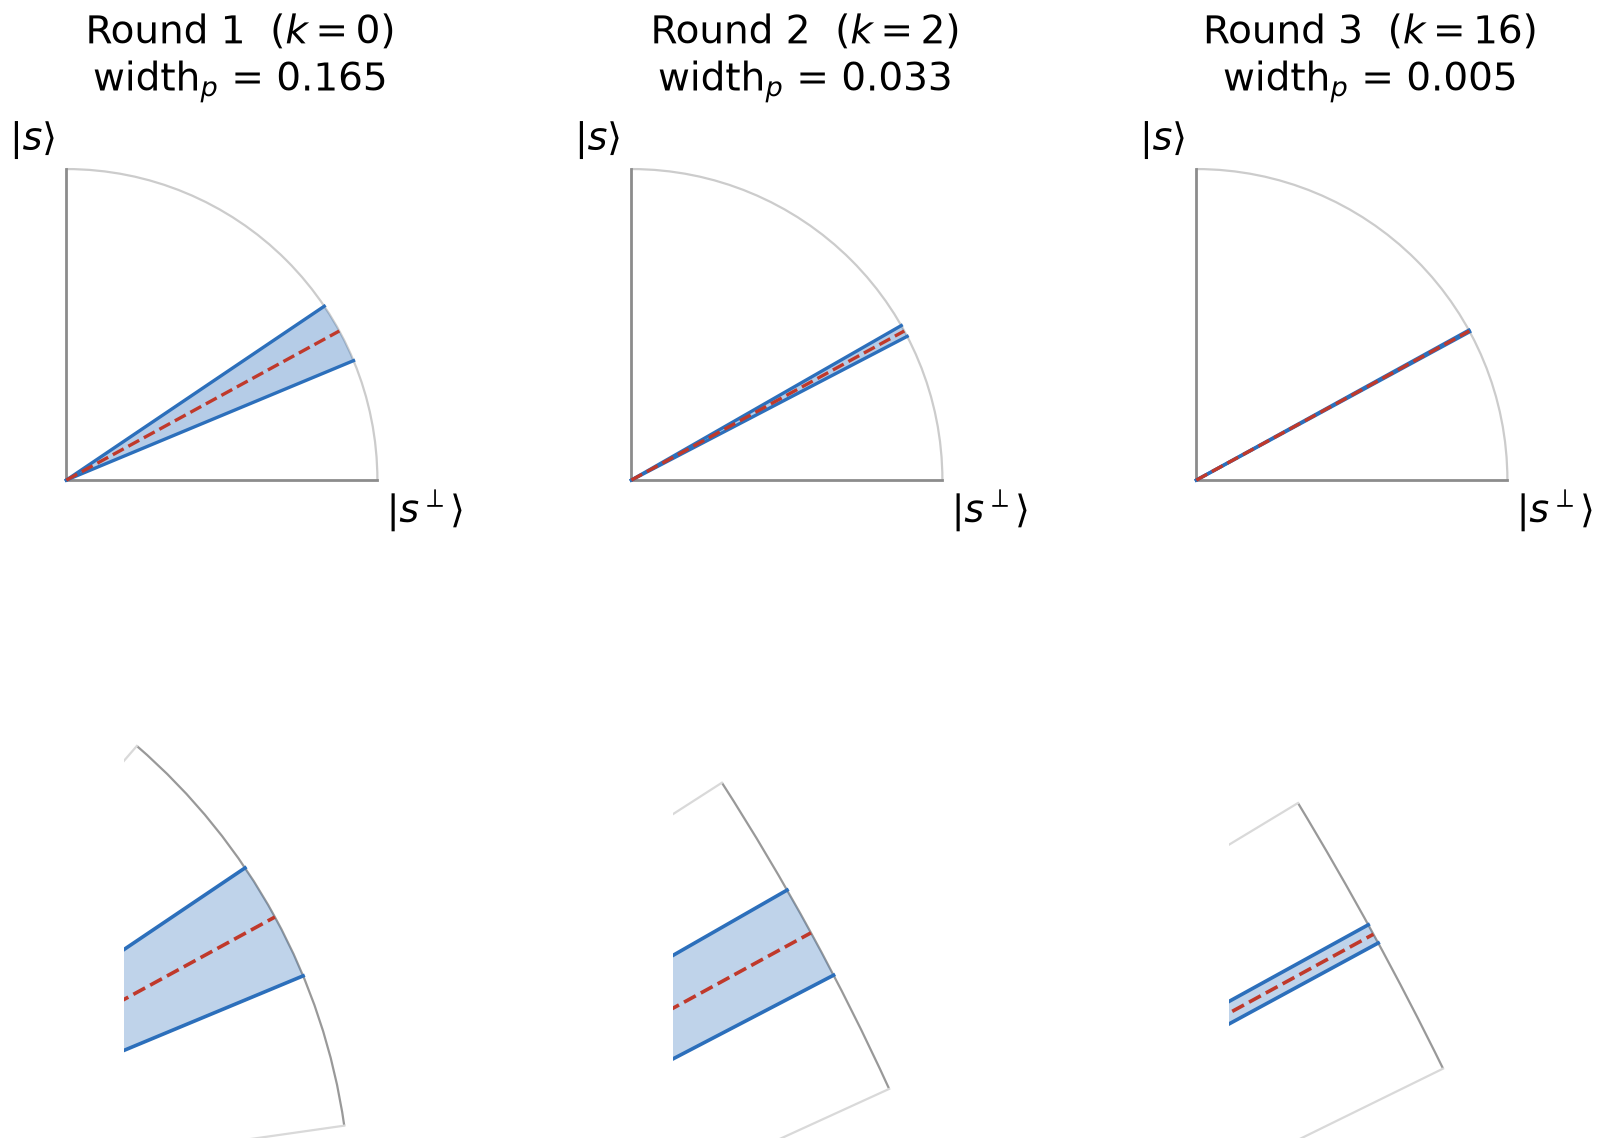

In [8]:

from Chapter15_QAE_functions import (iqae, print_table, plot_rounds_wedge, plot_rounds_linear)

THETA_TRUE = 0.5                       # hidden truth; p = sin^2(0.5) = 0.2298

# ---- reproduce the worked example in the text -------------------
print("Worked example (fixed counts 23, 36, 51):")
book = iqae(THETA_TRUE, N=100, max_rounds=3, fixed_counts=[23, 36, 51])
print_table(book)
plot_rounds_wedge(book, theta_true=0.5);


Reader run (random sampling, 6 rounds, seed=1):
  [round 3: confidence miss, interval reset]
  [round 4: confidence miss, interval reset]


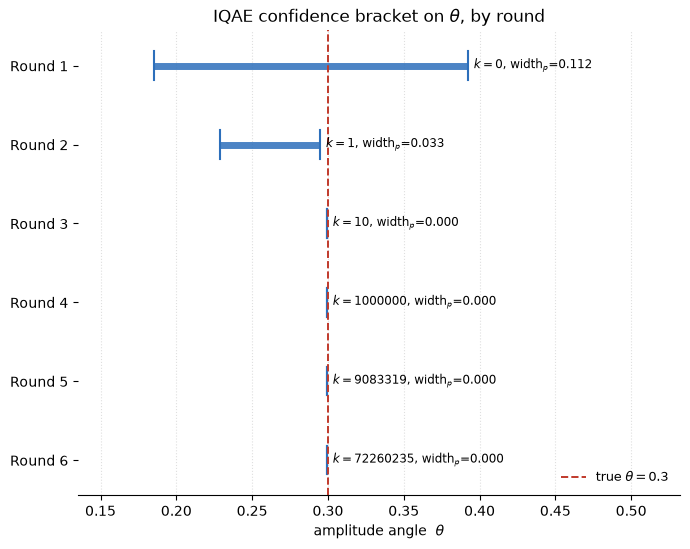

In [9]:
# ---- reader can run any number of rounds with real sampling -----
print("\nReader run (random sampling, 6 rounds, seed=1):")
theta_true = 0.3
demo = iqae(theta_true, N=100, max_rounds=6, seed=1, fixed_counts=None)
plot_rounds_linear(demo, theta_true=theta_true);

## Qiskit IQAE

In [10]:
theta   = np.pi / 6
p = np.sin(theta)**2   # 0.25

epsilon_target = 0.01
# State preparation: U_psi = R_y(2 theta)
U_psi = QuantumCircuit(1)
U_psi.ry(2*theta, 0)

# Good state = |1> on qubit 0
problem = EstimationProblem(state_preparation=U_psi, objective_qubits=[0])

# Target precision for 95% confidence
iqae = IterativeAmplitudeEstimation(epsilon_target=epsilon_target,alpha=0.05,sampler=StatevectorSampler())
result = iqae.estimate(problem)
CI = result.confidence_interval
print(f"True p:            {p:.7f}")
print(f"Epsilon target:    {epsilon_target:.7f}")
print(f"IQAE estimate:     {result.estimation:.7f}")
print(f"95% CI:            [{CI[0]:.7f}, {CI[1]:.7f}]")
print(f"Oracle queries:    {result.num_oracle_queries}")
print(f"k schedule:        {result.powers}")

True p:            0.2500000
Epsilon target:    0.0100000
IQAE estimate:     0.2489755
95% CI:            [0.2461440, 0.2518071]
Oracle queries:    6144
k schedule:        [0, 0, 6]


## Application: Estimating Area Fraction

## Plot microstructure


Target inclusion fraction: 0.250
Actual inclusion fraction: 0.250


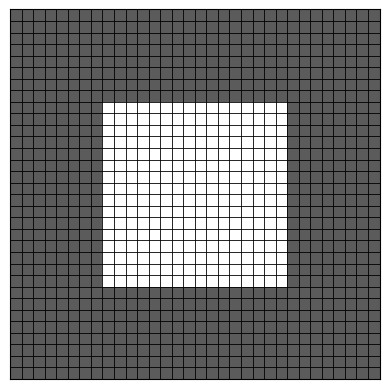

In [11]:
from Chapter04_EngineeringProblems_functions import MicrostructureGenerator
m = 5
micro = MicrostructureGenerator(2**m, 2**m, inclusion_fraction=0.25, micro_type='square')
micro.plot()

Centered square hole in 2^3 x 2^3 grid (area fraction 1/4):


--- Circuit Analysis ---
Qubits: 9
Single-qubit gates: 14
CX/ECR gates: 14
Total gates: 28
Depth: 15


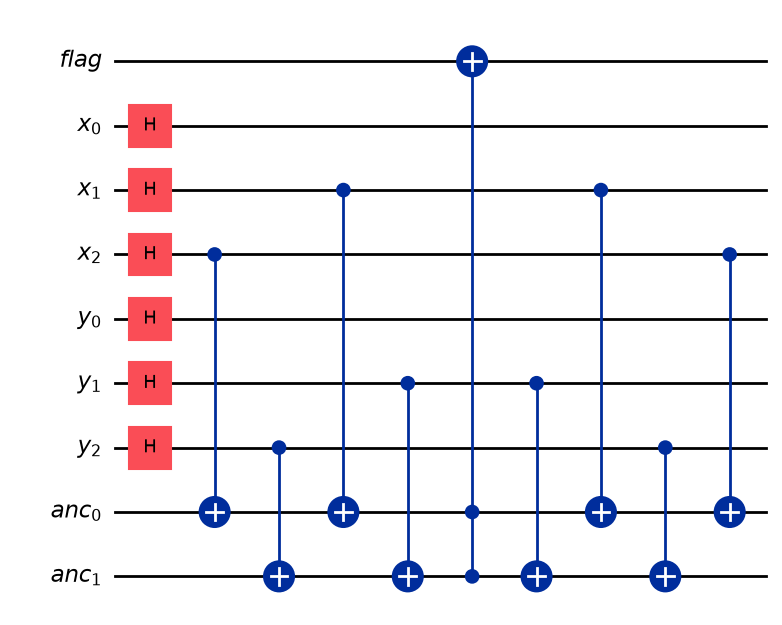

In [12]:
from Chapter08_QuantumGates_functions import estimateCircuitGates

def square_hole_U_psi(m):
    """2^m x 2^m grid with a centered square hole of side N/2 (area fraction 1/4).
    Requires m >= 2.  Good state = flag |1> on the hole.

    Key fact: a centered hole spans x in [N/4, 3N/4), and inspecting the top two
    bits of x shows that range is exactly  x_{m-1} XOR x_{m-2} = 1  (top two bits
    differ; lower bits irrelevant).  So the oracle touches only the top two bits
    of each coordinate -- the same tiny circuit for every m:
        inside = (x_{m-1} ^ x_{m-2}) AND (y_{m-1} ^ y_{m-2})."""
    if m < 2:
        raise ValueError("need m >= 2 for a centered 25% hole")
    flag = QuantumRegister(1, "flag")
    x    = QuantumRegister(m, "x")
    y    = QuantumRegister(m, "y")
    anc  = QuantumRegister(2, "anc")
    U_psi = QuantumCircuit(flag, x, y, anc)

    U_psi.h(x); U_psi.h(y)                           # uniform over all 2^(2m) cells
    U_psi.cx(x[m-1], anc[0]); U_psi.cx(x[m-2], anc[0]) # anc0 = x_{m-1} ^ x_{m-2}
    U_psi.cx(y[m-1], anc[1]); U_psi.cx(y[m-2], anc[1]) # anc1 = y_{m-1} ^ y_{m-2}
    U_psi.ccx(anc[0], anc[1], flag[0])               # flag = inside hole
    U_psi.cx(y[m-2], anc[1]); U_psi.cx(y[m-1], anc[1])       # uncompute ancillas
    U_psi.cx(x[m-2], anc[0]); U_psi.cx(x[m-1], anc[0])
    return U_psi, [0]                                    # objective_qubits = [flag]

m = 3
print(f"Centered square hole in 2^{m} x 2^{m} grid (area fraction 1/4):")
U_psi, objective = square_hole_U_psi(m)
estimateCircuitGates(U_psi);
display(U_psi.draw('mpl', fold=10))

### Use IQAE to find area fraction

In [13]:

epsilon_target = 0.01
problem = EstimationProblem(state_preparation=U_psi, objective_qubits=objective)
iqae = IterativeAmplitudeEstimation(epsilon_target=epsilon_target, alpha=0.05,
                                    sampler=StatevectorSampler())
res = iqae.estimate(problem)
lo, hi = res.confidence_interval
print(f"True area fraction:  0.2500")
print(f"Epsilon target:     {epsilon_target:.6f}")
print(f"IQAE estimate:       {res.estimation:.4f}")
print(f"95% CI:              [{float(lo):.4f}, {float(hi):.4f}]")
print(f"Oracle queries:      {res.num_oracle_queries}")
print(f"k schedule:         {res.powers}")

True area fraction:  0.2500
Epsilon target:     0.010000
IQAE estimate:       0.2505
95% CI:              [0.2472, 0.2539]
Oracle queries:      5120
k schedule:         [0, 0, 5]


### Application: ICU Observable

In [14]:
from Chapter15_QAE_functions import build_observable_circuit
# --- Problem definition ---
f = np.array([1., 0., 0.5, 0.2])
f = f / np.linalg.norm(f)
A_mat = np.array([[ 1.,  0.,  0., -0.5],
                  [ 0.,  1.,  0.,  0. ],
                  [ 0.,  0.,  1.,  0. ],
                  [-0.5, 0.,  0.,  1. ]])
x_vec     = np.array([0.6, 0.8, 0., 0.])
classical = np.abs(f @ A_mat @ x_vec)

# --- Build circuit ---
A_obs, metadata = build_observable_circuit(A_mat, x_vec, f)
alpha_lcu  = metadata['alpha']
p_succ     = metadata['p_success']
good_qubits = metadata['good_qubits']

# --- Statevector diagnostics ---
num_anc = metadata['num_ancilla']
num_sys = metadata['num_system']
sv = Statevector(A_obs)
probs = sv.probabilities_dict()


# --- Run IQAE ---
problem = EstimationProblem(state_preparation=A_obs, objective_qubits=good_qubits)
iqae    = IterativeAmplitudeEstimation(epsilon_target=0.01, alpha=0.05,
                                       sampler=StatevectorSampler())
result  = iqae.estimate(problem)

a_hat, (a_lo, a_hi) = result.estimation, result.confidence_interval

# --- Recovery formula ---
obs_hat = np.sqrt(a_hat) * alpha_lcu * np.sqrt(p_succ)
obs_lo  = np.sqrt(a_lo)  * alpha_lcu * np.sqrt(p_succ)
obs_hi  = np.sqrt(a_hi)  * alpha_lcu * np.sqrt(p_succ)

print("=== Results ===")
print(f"Classical:           {classical:.4f}")
print(f"IQAE estimate:       {obs_hat:.4f}")
print(f"95% CI:              [{obs_lo:.4f}, {obs_hi:.4f}]")
print(f"Oracle queries:      {result.num_oracle_queries}")
print(f"k schedule:        {result.powers}")


=== Results ===
Classical:           0.4754
IQAE estimate:       0.4768
95% CI:              [0.4741, 0.4794]
Oracle queries:      7168
k schedule:        [0, 0, 7]
